## 4. Modelling: TF-IDF + ML Classifiers, and VADER Lexicon Baseline
Trains Logistic Regression, Multinomial Naive Bayes and Linear SVM on TF-IDF features; compares against an unsupervised VADER lexicon baseline; visualises confusion matrix and top predictive words.

In [2]:
!pip install vaderSentiment


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


DATASET INFORMATION
Original dataset shape: (22366, 14)
Rows used for modelling: 22366

Columns:
['reviewer_id', 'store_name', 'category', 'store_address', 'latitude', 'longitude', 'rating_count_num', 'review_time', 'days_ago', 'review_clean', 'rating_num', 'sentiment', 'is_autotag', 'review_processed']

Sentiment distribution:
sentiment
Positive    9762
Negative    9440
Neutral     3164
Name: count, dtype: int64

Sentiment proportions:
sentiment
Positive    0.4365
Negative    0.4221
Neutral     0.1415
Name: proportion, dtype: float64

TRAIN-TEST SPLIT
Training samples: 17892
Testing samples : 4474

Training sentiment distribution:
sentiment
Positive    7809
Negative    7552
Neutral     2531
Name: count, dtype: int64

Testing sentiment distribution:
sentiment
Positive    1953
Negative    1888
Neutral      633
Name: count, dtype: int64

TF-IDF INFORMATION
Training matrix shape: (17892, 20000)
Testing matrix shape : (4474, 20000)
Number of TF-IDF features: 20000

MODEL TRAINING AND EVALU

,accuracy,macro_precision,macro_recall,macro_f1
Logistic Regression,0.7405,0.6711,0.6780,0.6701
Linear SVM,0.7456,0.6434,0.6423,0.6426
Multinomial Naive Bayes,0.7664,0.7535,0.5982,0.5576



BEST MODEL
Best model by Macro-F1: Logistic Regression
Macro-F1: 0.6701
Accuracy: 0.7405
Macro Precision: 0.6711
Macro Recall: 0.6780


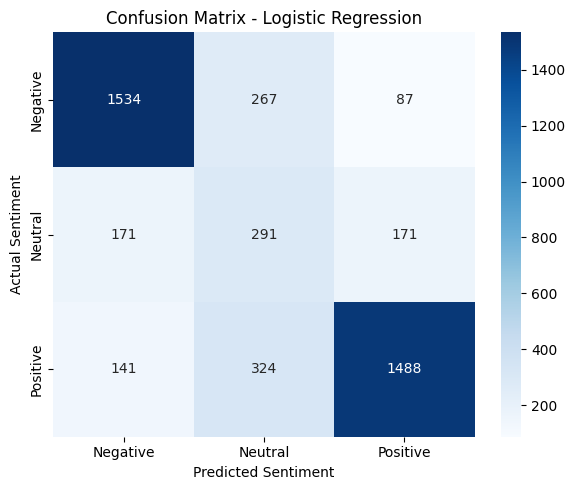

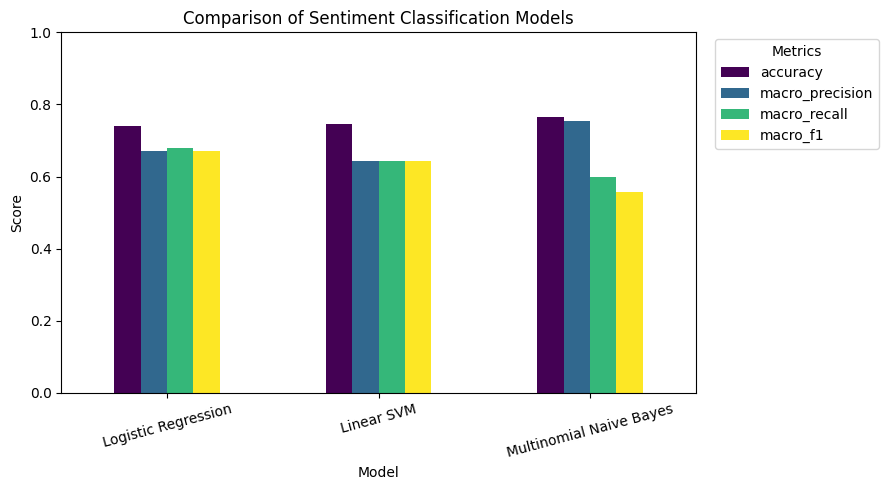


TOP PREDICTIVE WORDS — LOGISTIC REGRESSION

Top predictive features for Negative:
worst                          5.0758
not                            3.9064
horrible                       3.8397
rude                           3.5944
terrible                       3.5078
minutes                        2.8781
dirty                          2.7730
awful                          2.6799
never                          2.6519
no                             2.5492
not good                       2.4128
the worst                      2.3913
poor                           2.3786
closed                         2.3028
gross                          2.2352

Top predictive features for Neutral:
okay                           2.1697
but                            2.1555
long                           2.1239
kinda                          1.8997
however                        1.7942
not great                      1.7572
average                        1.5088
fast                           1.5058
good 

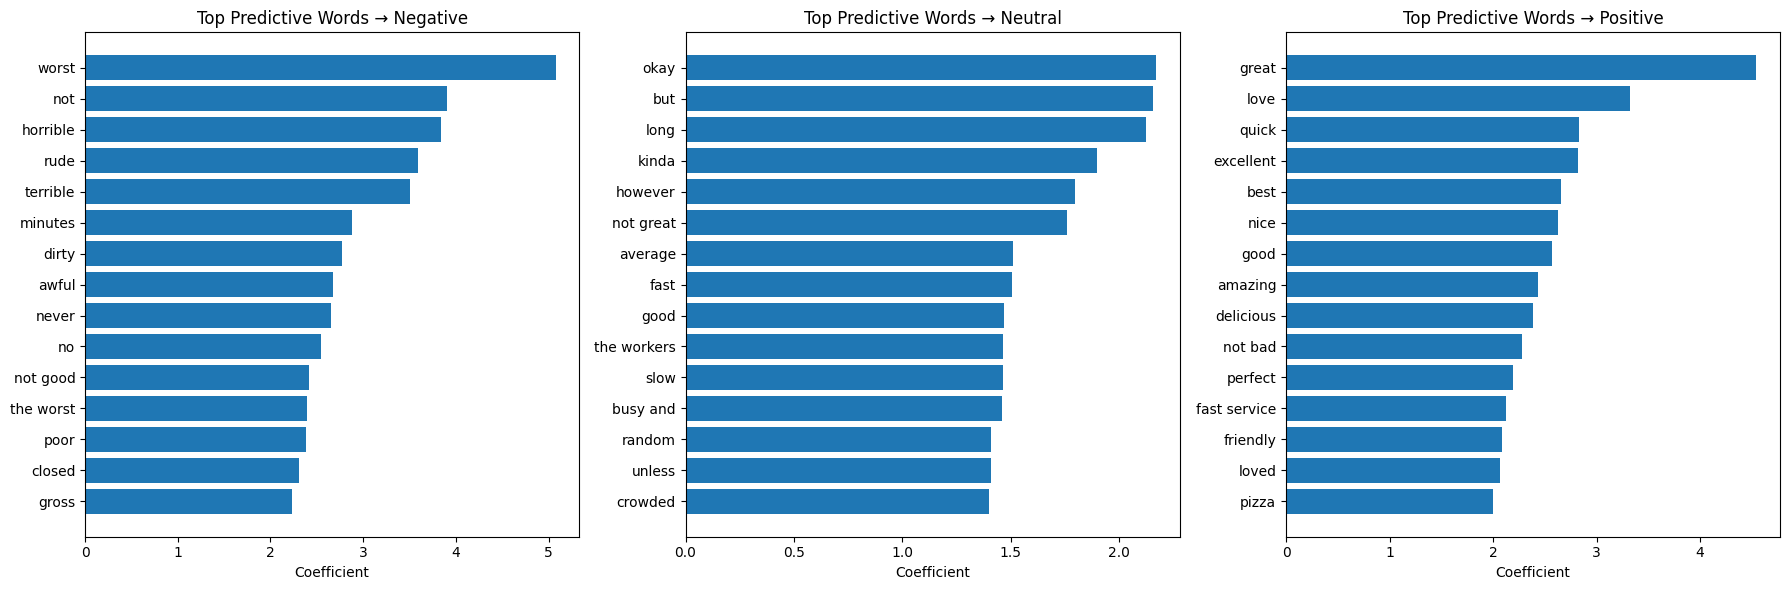


VADER LEXICON-BASED BASELINE
VADER Accuracy      : 0.6434
VADER Macro Precision: 0.5752
VADER Macro Recall   : 0.5628
VADER Macro-F1       : 0.5627

VADER Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.63      0.71      3370
     Neutral       0.21      0.28      0.24      1144
    Positive       0.70      0.77      0.74      3486

    accuracy                           0.64      8000
   macro avg       0.58      0.56      0.56      8000
weighted avg       0.68      0.64      0.65      8000



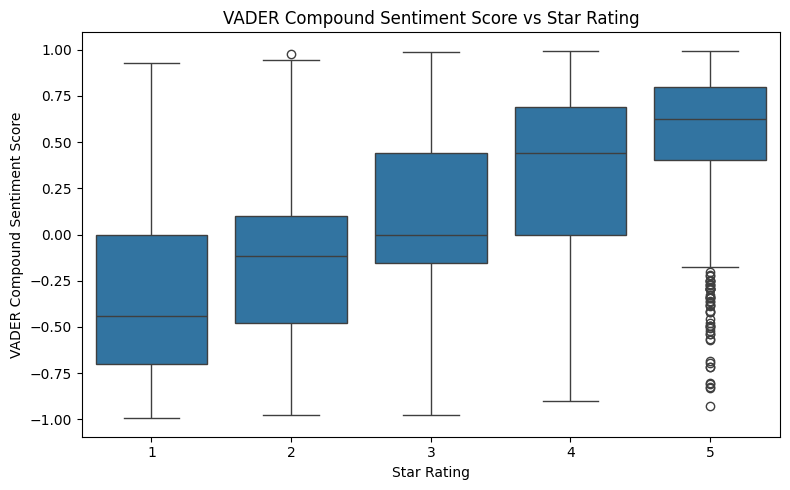

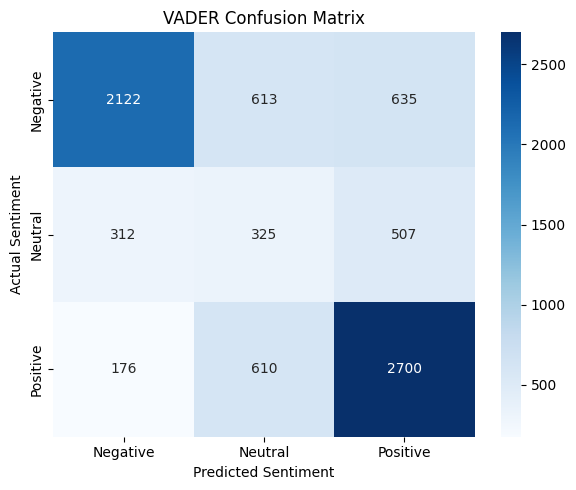


SUPERVISED MODELS VS VADER


,accuracy,macro_precision,macro_recall,macro_f1
Logistic Regression,0.7405,0.6711,0.6780,0.6701
Linear SVM,0.7456,0.6434,0.6423,0.6426
Multinomial Naive Bayes,0.7664,0.7535,0.5982,0.5576
VADER,0.6434,0.5752,0.5628,0.5627



MODEL SAVING
Best model saved to:
../models\best_sentiment_model.pkl

TF-IDF vectorizer saved to:
../models\tfidf_vectorizer.pkl

TESTING SAVED MODEL

Example Predictions:

Review: The product is excellent and I really love it.
Predicted sentiment: Positive

Review: The product is okay, nothing special.
Predicted sentiment: Neutral

Review: Very bad quality and completely disappointing.
Predicted sentiment: Negative

NOTEBOOK 04 COMPLETED SUCCESSFULLY
Best model       : Logistic Regression
Best Macro-F1    : 0.6701
Best Accuracy    : 0.7405
VADER Macro-F1   : 0.5627
Training samples : 17892
Testing samples  : 4474
TF-IDF features  : 20000

Saved files:
- ../results/model_results.csv
- ../results/classification_reports.txt
- ../results/vader_classification_report.txt
- ../results/supervised_vs_vader.csv
- ../results/summary.json
- ../models/best_sentiment_model.pkl
- ../models/tfidf_vectorizer.pkl
- ../models/logistic_regression_model.pkl
- ../Figures/07_confusion_matrix.png
- ../Figur

In [4]:
# ================================================================
# NOTEBOOK 04 — SENTIMENT CLASSIFICATION MODELING
# ================================================================
# Purpose:
#   1. Load processed review text
#   2. Split data into training and testing sets
#   3. Convert text into TF-IDF features
#   4. Train multiple supervised ML models
#   5. Evaluate models using Accuracy, Precision, Recall and Macro-F1
#   6. Select the best model based on Macro-F1
#   7. Generate confusion matrix
#   8. Visualize model performance
#   9. Identify influential words using Logistic Regression
#  10. Compare VADER with rating-derived sentiment labels
#  11. Save results, figures, model and vectorizer
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

%matplotlib inline

import os
import json
import joblib
import warnings

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# Suppress unnecessary warnings
warnings.filterwarnings("ignore")


# ================================================================
# 2. PATH CONFIGURATION
# ================================================================

DATA_PATH = "text_reviews_processed.csv"

RESULTS_DIR = "../results"
MODELS_DIR = "../models"
FIG_DIR = "../Figures"

# Create folders automatically if they do not exist
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)


# ================================================================
# 3. LOAD DATA
# ================================================================

df = pd.read_csv(DATA_PATH)

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Original dataset shape:", df.shape)

# Remove rows without processed review text
df = df.dropna(subset=["review_processed"]).copy()

print("Rows used for modelling:", len(df))

print("\nColumns:")
print(df.columns.tolist())

print("\nSentiment distribution:")
print(df["sentiment"].value_counts())

print("\nSentiment proportions:")
print(df["sentiment"].value_counts(normalize=True).round(4))


# ================================================================
# 4. DEFINE FEATURES AND TARGET
# ================================================================

X_text = df["review_processed"].astype(str)
y = df["sentiment"].astype(str)


# ================================================================
# 5. TRAIN-TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("TRAIN-TEST SPLIT")
print("=" * 70)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

print("\nTraining sentiment distribution:")
print(y_train.value_counts())

print("\nTesting sentiment distribution:")
print(y_test.value_counts())


# ================================================================
# 6. TF-IDF FEATURE EXTRACTION
# ================================================================

tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 3),
    min_df=3,
    sublinear_tf=True
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

print("\n" + "=" * 70)
print("TF-IDF INFORMATION")
print("=" * 70)

print("Training matrix shape:", X_train_vec.shape)
print("Testing matrix shape :", X_test_vec.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))


# ================================================================
# 7. DEFINE MACHINE LEARNING MODELS
# ================================================================

models = {

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Multinomial Naive Bayes": MultinomialNB(),

    "Linear SVM": LinearSVC(
        class_weight="balanced",
        random_state=42
    )
}


# ================================================================
# 8. TRAIN AND EVALUATE MODELS
# ================================================================

results = {}
preds_store = {}
classification_reports = {}

print("\n" + "=" * 70)
print("MODEL TRAINING AND EVALUATION")
print("=" * 70)

for name, model in models.items():

    print(f"\nTraining: {name}")

    # Train model
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred = model.predict(X_test_vec)

    # Store predictions
    preds_store[name] = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        y_pred,
        average="macro",
        zero_division=0
    )

    results[name] = {
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": f1
    }

    # Classification report
    report = classification_report(
        y_test,
        y_pred,
        zero_division=0
    )

    classification_reports[name] = report

    print("\n" + "-" * 70)
    print(name)
    print("-" * 70)

    print(report)


# ================================================================
# 9. MODEL COMPARISON TABLE
# ================================================================

results_df = pd.DataFrame(results).T

results_df = results_df.sort_values(
    by="macro_f1",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(results_df.round(4))


# Save model comparison
results_df.to_csv(
    os.path.join(RESULTS_DIR, "model_results.csv")
)


# ================================================================
# 10. SAVE CLASSIFICATION REPORTS
# ================================================================

with open(
    os.path.join(RESULTS_DIR, "classification_reports.txt"),
    "w",
    encoding="utf-8"
) as f:

    for name, report in classification_reports.items():

        f.write("=" * 80 + "\n")
        f.write(name + "\n")
        f.write("=" * 80 + "\n")
        f.write(report)
        f.write("\n\n")


# ================================================================
# 11. BEST MODEL SELECTION
# ================================================================

best_name = results_df["macro_f1"].idxmax()

best_model = models[best_name]
best_predictions = preds_store[best_name]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(f"Best model by Macro-F1: {best_name}")
print(
    f"Macro-F1: "
    f"{results_df.loc[best_name, 'macro_f1']:.4f}"
)
print(
    f"Accuracy: "
    f"{results_df.loc[best_name, 'accuracy']:.4f}"
)
print(
    f"Macro Precision: "
    f"{results_df.loc[best_name, 'macro_precision']:.4f}"
)
print(
    f"Macro Recall: "
    f"{results_df.loc[best_name, 'macro_recall']:.4f}"
)


# ================================================================
# 12. CONFUSION MATRIX FOR BEST MODEL
# ================================================================

order = [
    "Negative",
    "Neutral",
    "Positive"
]

cm = confusion_matrix(
    y_test,
    best_predictions,
    labels=order
)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=order,
    yticklabels=order,
    ax=ax
)

ax.set_xlabel("Predicted Sentiment")
ax.set_ylabel("Actual Sentiment")
ax.set_title(f"Confusion Matrix - {best_name}")

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "07_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 13. MODEL COMPARISON BAR CHART
# ================================================================

metrics = [
    "accuracy",
    "macro_precision",
    "macro_recall",
    "macro_f1"
]

fig, ax = plt.subplots(figsize=(9, 5))

results_df[metrics].plot(
    kind="bar",
    ax=ax,
    colormap="viridis"
)

ax.set_title("Comparison of Sentiment Classification Models")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)

plt.xticks(rotation=15)
plt.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    os.path.join(FIG_DIR, "08_model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 14. LOGISTIC REGRESSION — MOST INFLUENTIAL WORDS
# ================================================================

logreg = models["Logistic Regression"]

feat_names = np.array(
    tfidf.get_feature_names_out()
)

print("\n" + "=" * 70)
print("TOP PREDICTIVE WORDS — LOGISTIC REGRESSION")
print("=" * 70)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for ax, cls in zip(axes, order):

    # Find class index
    idx = list(logreg.classes_).index(cls)

    # Get coefficients
    coefs = logreg.coef_[idx]

    # Select 15 strongest positive coefficients
    top_idx = np.argsort(coefs)[-15:]

    top_words = feat_names[top_idx]
    top_values = coefs[top_idx]

    # Print words
    print(f"\nTop predictive features for {cls}:")
    for word, value in zip(
        reversed(top_words),
        reversed(top_values)
    ):
        print(f"{word:30s} {value:.4f}")

    ax.barh(
        top_words,
        top_values
    )

    ax.set_title(
        f"Top Predictive Words → {cls}"
    )

    ax.set_xlabel("Coefficient")


plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "09_top_predictive_words.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 15. VADER SENTIMENT ANALYSIS
# ================================================================

print("\n" + "=" * 70)
print("VADER LEXICON-BASED BASELINE")
print("=" * 70)

analyzer = SentimentIntensityAnalyzer()

# Use maximum 8,000 reviews for VADER analysis
sample = df.sample(
    n=min(8000, len(df)),
    random_state=42
).copy()


# Use cleaned text for VADER
sample["vader_compound"] = (
    sample["review_clean"]
    .astype(str)
    .apply(
        lambda text:
        analyzer.polarity_scores(text)["compound"]
    )
)


# ================================================================
# 16. VADER SENTIMENT LABEL FUNCTION
# ================================================================

def vader_label(compound_score):

    if compound_score <= -0.05:
        return "Negative"

    elif compound_score >= 0.05:
        return "Positive"

    else:
        return "Neutral"


sample["vader_sentiment"] = (
    sample["vader_compound"]
    .apply(vader_label)
)


# ================================================================
# 17. VADER EVALUATION
# ================================================================

vader_accuracy = accuracy_score(
    sample["sentiment"],
    sample["vader_sentiment"]
)

vader_precision, vader_recall, vader_f1, _ = (
    precision_recall_fscore_support(
        sample["sentiment"],
        sample["vader_sentiment"],
        average="macro",
        zero_division=0
    )
)

print(
    f"VADER Accuracy      : {vader_accuracy:.4f}"
)

print(
    f"VADER Macro Precision: {vader_precision:.4f}"
)

print(
    f"VADER Macro Recall   : {vader_recall:.4f}"
)

print(
    f"VADER Macro-F1       : {vader_f1:.4f}"
)


# ================================================================
# 18. VADER CLASSIFICATION REPORT
# ================================================================

vader_report = classification_report(
    sample["sentiment"],
    sample["vader_sentiment"],
    zero_division=0
)

print("\nVADER Classification Report:")
print(vader_report)


# Save VADER report
with open(
    os.path.join(
        RESULTS_DIR,
        "vader_classification_report.txt"
    ),
    "w",
    encoding="utf-8"
) as f:

    f.write(vader_report)


# ================================================================
# 19. VADER VS STAR RATING
# ================================================================

if "rating_num" in sample.columns:

    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    sns.boxplot(
        data=sample,
        x="rating_num",
        y="vader_compound",
        ax=ax
    )

    ax.set_title(
        "VADER Compound Sentiment Score vs Star Rating"
    )

    ax.set_xlabel("Star Rating")

    ax.set_ylabel(
        "VADER Compound Sentiment Score"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIG_DIR,
            "10_vader_vs_rating.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(
        "\n'rating_num' column not found. "
        "Skipping VADER vs rating plot."
    )


# ================================================================
# 20. VADER CONFUSION MATRIX
# ================================================================

vader_cm = confusion_matrix(
    sample["sentiment"],
    sample["vader_sentiment"],
    labels=order
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

sns.heatmap(
    vader_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=order,
    yticklabels=order,
    ax=ax
)

ax.set_xlabel("Predicted Sentiment")
ax.set_ylabel("Actual Sentiment")

ax.set_title(
    "VADER Confusion Matrix"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIG_DIR,
        "11_vader_confusion_matrix.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ================================================================
# 21. SUPERVISED VS VADER COMPARISON
# ================================================================

comparison_data = results_df[
    [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1"
    ]
].copy()

comparison_data.loc[
    "VADER"
] = [
    vader_accuracy,
    vader_precision,
    vader_recall,
    vader_f1
]

print("\n" + "=" * 70)
print("SUPERVISED MODELS VS VADER")
print("=" * 70)

display(comparison_data.round(4))

comparison_data.to_csv(
    os.path.join(
        RESULTS_DIR,
        "supervised_vs_vader.csv"
    )
)


# ================================================================
# 22. SAVE BEST MODEL
# ================================================================

model_path = os.path.join(
    MODELS_DIR,
    "best_sentiment_model.pkl"
)

vectorizer_path = os.path.join(
    MODELS_DIR,
    "tfidf_vectorizer.pkl"
)

joblib.dump(
    best_model,
    model_path
)

joblib.dump(
    tfidf,
    vectorizer_path
)

print("\n" + "=" * 70)
print("MODEL SAVING")
print("=" * 70)

print("Best model saved to:")
print(model_path)

print("\nTF-IDF vectorizer saved to:")
print(vectorizer_path)


# ================================================================
# 23. OPTIONAL — SAVE LOGISTIC REGRESSION MODEL
# ================================================================

joblib.dump(
    logreg,
    os.path.join(
        MODELS_DIR,
        "logistic_regression_model.pkl"
    )
)


# ================================================================
# 24. SAVE MODEL SUMMARY
# ================================================================

summary = {

    "best_supervised_model": best_name,

    "best_supervised_accuracy":
        float(
            results_df.loc[
                best_name,
                "accuracy"
            ]
        ),

    "best_supervised_macro_precision":
        float(
            results_df.loc[
                best_name,
                "macro_precision"
            ]
        ),

    "best_supervised_macro_recall":
        float(
            results_df.loc[
                best_name,
                "macro_recall"
            ]
        ),

    "best_supervised_macro_f1":
        float(
            results_df.loc[
                best_name,
                "macro_f1"
            ]
        ),

    "vader_accuracy":
        float(vader_accuracy),

    "vader_macro_precision":
        float(vader_precision),

    "vader_macro_recall":
        float(vader_recall),

    "vader_macro_f1":
        float(vader_f1),

    "n_total":
        int(len(df)),

    "n_train":
        int(len(X_train)),

    "n_test":
        int(len(X_test)),

    "tfidf_features":
        int(len(tfidf.get_feature_names_out())),

    "test_size":
        0.20,

    "random_state":
        42
}


with open(
    os.path.join(
        RESULTS_DIR,
        "summary.json"
    ),
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ================================================================
# 25. TEST SAVED MODEL
# ================================================================

print("\n" + "=" * 70)
print("TESTING SAVED MODEL")
print("=" * 70)

# Load saved model and vectorizer
loaded_model = joblib.load(model_path)
loaded_tfidf = joblib.load(vectorizer_path)


# Example reviews
example_reviews = [
    "The product is excellent and I really love it.",
    "The product is okay, nothing special.",
    "Very bad quality and completely disappointing."
]


example_vectors = loaded_tfidf.transform(
    example_reviews
)

example_predictions = loaded_model.predict(
    example_vectors
)

print("\nExample Predictions:")

for review, prediction in zip(
    example_reviews,
    example_predictions
):

    print(f"\nReview: {review}")
    print(f"Predicted sentiment: {prediction}")


# ================================================================
# 26. FINAL OUTPUT SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(f"Best model       : {best_name}")
print(
    f"Best Macro-F1    : "
    f"{results_df.loc[best_name, 'macro_f1']:.4f}"
)

print(
    f"Best Accuracy    : "
    f"{results_df.loc[best_name, 'accuracy']:.4f}"
)

print(
    f"VADER Macro-F1   : "
    f"{vader_f1:.4f}"
)

print(
    f"Training samples : {len(X_train)}"
)

print(
    f"Testing samples  : {len(X_test)}"
)

print(
    f"TF-IDF features  : "
    f"{len(tfidf.get_feature_names_out())}"
)

print("\nSaved files:")

print(
    "- ../results/model_results.csv"
)

print(
    "- ../results/classification_reports.txt"
)

print(
    "- ../results/vader_classification_report.txt"
)

print(
    "- ../results/supervised_vs_vader.csv"
)

print(
    "- ../results/summary.json"
)

print(
    "- ../models/best_sentiment_model.pkl"
)

print(
    "- ../models/tfidf_vectorizer.pkl"
)

print(
    "- ../models/logistic_regression_model.pkl"
)

print(
    "- ../Figures/07_confusion_matrix.png"
)

print(
    "- ../Figures/08_model_comparison.png"
)

print(
    "- ../Figures/09_top_predictive_words.png"
)

print(
    "- ../Figures/10_vader_vs_rating.png"
)

print(
    "- ../Figures/11_vader_confusion_matrix.png"
)

print("\nAll model outputs and figures have been saved.")